In [ ]:
# This file runs functions to find the number of people affected
# in buffers or oil and gas wells. 

In [21]:
import pathlib
import sys
#from matplotlib import pyplot as plt

# Define base path
repo = pathlib.Path.cwd().parent

# Define data paths

# location of the oil and gas data
oil_path = pathlib.Path("/Users/ninaflores/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data/environmental/oil_and_gas/raw_data/ogim.parquet")

# location of the adminstrative boundary shapefile
countries_path = pathlib.Path("/Users/ninaflores/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data/geo_boundaries/processed_data/country_admin/admin2_geom.parquet")
#countries_path = pathlib.Path("/Users/ninaflores/Documents/repos/casey_lab_shared_functions/wf_disaster_exp_by_geo/demo_data/oil-gas/Mozambique_detailed_boundary.parquet")
#countries_path = pathlib.Path("/Users/ninaflores/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data/geo_boundaries/processed_data/country_admin/admin2_md.parquet")
#countries_path = pathlib.Path("/Users/ninaflores//Desktop/projects/casey cohort/OGW/data/processed-data/Georgia_detailed_boundary.parquet")



# location of the population data
ghs_pop_path = pathlib.Path('/Users/ninaflores/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data/social_including_census/raw_data/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0.tif')

# Define code path and add to sys.path
code_path = repo / "code"

# Import local modules
from num_people_affected_helpers_partial_pixels_option_2 import *


In [22]:
# need to look at wfs and pass the right thing
# read oil
oil = gpd.read_parquet(oil_path)
print(oil.head())  

#print("CRS of oil GeoDataFrame:", oil.crs)

country = gpd.read_parquet(countries_path)

print(country.head())  
#print("CRS of country GeoDataFrame:", country.crs)

# Open the .tif file using rasterio
with rasterio.open(ghs_pop_path) as src:
    # Print the metadata of the file to verify it is correctly located
    print(src.meta)

                     id                     geometry
0  0000000000000001a164  POINT (129.98255 -30.65631)
1  0000000000000001a165  POINT (133.44221 -27.39396)
2  0000000000000001a168  POINT (131.46529 -29.61509)
3  0000000000000001a16a  POINT (133.88599 -33.49271)
4  0000000000000001a16b   POINT (134.23862 -33.5617)
          id                                           geometry
0  1001143.0  MULTIPOLYGON (((-102.09772 22.0232, -102.0978 ...
1  2001143.0  MULTIPOLYGON (((-101.99941 22.21928, -101.9991...
2  3001143.0  MULTIPOLYGON (((-102.57623 21.96773, -102.5762...
3  4001143.0  MULTIPOLYGON (((-102.25319 22.37465, -102.2528...
4  5001143.0  MULTIPOLYGON (((-101.89796 21.95869, -101.8981...
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': -200.0, 'width': 360820, 'height': 180000, 'count': 1, 'crs': CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],

Oil GeoDataFrame head:
                     id                    geometry
0  0000000000000000a246  POINT (35.03877 -21.71659)
1  0000000000000000a247  POINT (34.99138 -21.72565)
2  0000000000000000a248  POINT (35.04196 -21.70081)
3  0000000000000000a249  POINT (35.05676 -21.73361)
4  0000000000000000a24a  POINT (35.08979 -21.70594)
CRS of oil GeoDataFrame: GEOGCRS["WGS 84",
    DATUM["World Geodetic System 1984",
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    ID["EPSG",4326]]
Country GeoDataFrame head:
      geo_id                                           geometry
0  1001143.0  MULTIPOLYGON (((-102.09772 22

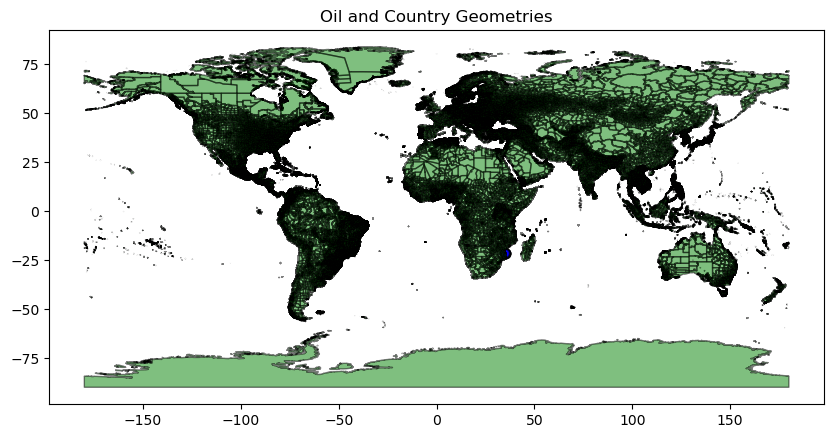

In [3]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Read the data files
oil = gpd.read_parquet(oil_path)
country = gpd.read_parquet(countries_path)

# Print the heads of the data files
print("Oil GeoDataFrame head:")
print(oil.head())
print("CRS of oil GeoDataFrame:", oil.crs)

print("Country GeoDataFrame head:")
print(country.head())
print("CRS of country GeoDataFrame:", country.crs)

# Plot the geometries
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
oil.plot(ax=ax, color='blue', edgecolor='black', alpha=0.5)
country.plot(ax=ax, color='green', edgecolor='black', alpha=0.5)
plt.title("Geometry file")
plt.show()

In [25]:
# can use this and the next cell to plot what's happening with the function 
# probably want to test this with a few different countries to ensure it's behaving
# as expected - but running on all countries will take a long time.

ch_df = prep_geographies(oil_path, geo_type="hazard")

#ch_shp = add_buffer_distance_col(
  #  ch_df,
  #  buffer_dist_large=1000,
  #  buffer_dist_small=1000,
  #  area_thresh_for_large_buffer=1,
  ##  )

#print(ch_shp.head())

# add buffered geom col
#ch_shp = add_buffered_geom_col(ch_shp)

#print(ch_shp.head())



TypeError: prep_geographies() got an unexpected keyword argument 'path_to_additional_geos'

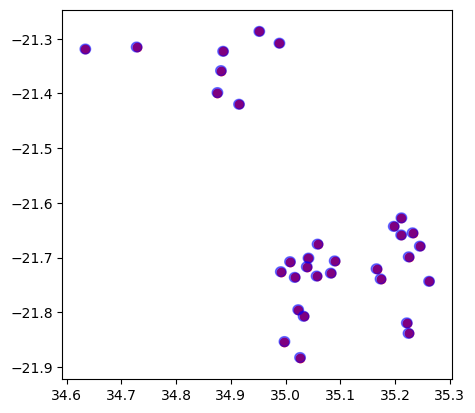

In [7]:
#fig, ax = plt.subplots()

# Temporarily set 'buffered_hazard' as the active geometry column and plot it
# Overlay the original geometries
#ch_df.set_geometry('geometry').plot(ax=ax, color='red', edgecolor='red')

#ch_df.set_geometry('buffered_hazard').plot(ax=ax, color='blue', alpha=0.5, edgecolor='blue')


##ax.set_ylim([ -24, -20])
##ax.set_xlim([30, 40])
# Show the plot
#plt.show()

In [23]:

num_af_by_bound = find_num_people_affected_by_geo(
    path_to_hazards=oil_path,
    path_to_additional_geos=countries_path,
    raster_path=ghs_pop_path,
    buffer_dist_large=1000,
    buffer_dist_small=1000,
    area_thresh_for_large_buffer=1)

print(num_af_by_bound)


# troubleshooting to do: figure out why the new shapefile is causing the function to break
# when reading unit geometries, getting the following error message:
# IndexError: index 0 is out of bounds for axis 0 with size 0


Reading data and finding best UTM projection for hazard geometries (1/6)


/Users/ninaflores/Documents/repos/ogd/code/num_people_affected_helpers_partial_pixels_option_2.py:42: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ch_shp["centroid_lon"] = ch_shp.centroid.x
/Users/ninaflores/Documents/repos/ogd/code/num_people_affected_helpers_partial_pixels_option_2.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ch_shp["centroid_lat"] = ch_shp.centroid.y


Reading spatial unit geometries (1/6)


IndexError: index 0 is out of bounds for axis 0 with size 0